In [4]:
import os
import oracledb
from dotenv import load_dotenv
import pandas as pd

load_dotenv()

def create_cursor():
    connection = oracledb.connect(
        user=os.getenv("ORACLE_USER"),
        password=os.getenv("ORACLE_PASSWORD"),
        dsn=oracledb.makedsn("localhost", 1522, service_name="stu"),
    )
    cursor = connection.cursor()
    print("Connected to Oracle")
    return connection, cursor

# RQ1: How does average viewership and engagement of conservative and liberal YouTube channels change over time?

In [5]:
connection, cursor = create_cursor()

rq1_query = """
SELECT
lean,
year,
ROUND(AVG(view_count), 2) AS avg_views,
ROUND(AVG(like_count), 2) AS avg_likes,
ROUND(AVG(comment_count), 2) AS avg_comments,
ROUND(AVG(like_count) / AVG(view_count) * 100, 2) AS like_rate_percent,
ROUND(AVG(comment_count) / AVG(view_count) * 100, 2) AS comment_rate_percent
FROM youtube_videos
GROUP BY lean, year
ORDER BY year, lean
"""
cursor.execute(rq1_query)
results = cursor.fetchall()
rq1_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
display(rq1_df)

cursor.close()
connection.close()

Connected to Oracle


,LEAN,YEAR,AVG_VIEWS,AVG_LIKES,AVG_COMMENTS,LIKE_RATE_PERCENT,COMMENT_RATE_PERCENT
0,conservative,2018,98931.87,2807.23,472.17,2.84,0.48
1,liberal,2018,664.98,3.58,1.30,0.54,0.20
2,conservative,2019,147282.83,4106.68,806.75,2.79,0.55
3,liberal,2019,67.55,0.58,0.30,0.86,0.44
4,conservative,2020,2089483.87,77850.17,10907.93,3.73,0.52
5,liberal,2020,31.52,0.22,0.07,0.69,0.21
6,conservative,2021,4121860.32,168471.42,16030.22,4.09,0.39
7,liberal,2021,85.13,0.95,0.50,1.12,0.59
8,conservative,2022,3866259.97,165252.77,10849.80,4.27,0.28
9,liberal,2022,304115.98,6692.88,3497.28,2.20,1.15


LEAN,conservative,liberal
YEAR,,
2018,98931.87,664.98
2019,147282.83,67.55
2020,2089483.87,31.52
2021,4121860.32,85.13
2022,3866259.97,304115.98
2023,10121797.97,1506847.42
2024,4653955.03,877708.45
2025,1293953.02,767539.15


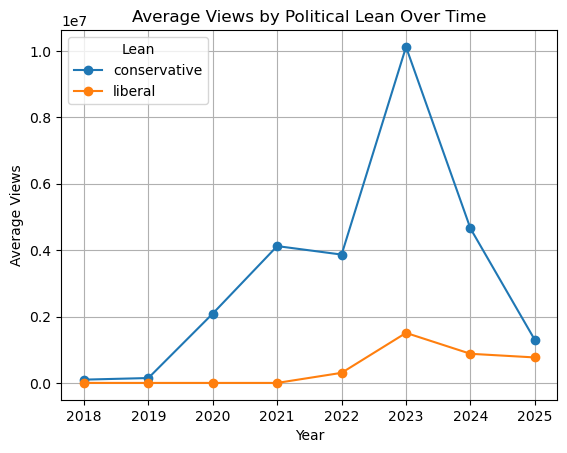

In [38]:
import matplotlib.pyplot as plt

pivot = rq1_df.pivot(index="YEAR", columns="LEAN", values="AVG_VIEWS")
display(pivot)
pivot.plot(marker="o")
plt.title("Average Views by Political Lean Over Time")
plt.xlabel("Year")
plt.ylabel("Average Views")
plt.legend(title="Lean")
plt.grid(True)
plt.show()

# RQ2: Are election years associated with significantly higher YouTube engagement on politically aligned channels compared to non-election years?

In [20]:
connection, cursor = create_cursor()
try: 
    rq2_query = """
SELECT
a.election_year,
a.youtube_use,
a.lib_con_scale,
COUNT(*) AS respondent_count,
ROUND(AVG(a.democrat_thermometer), 2) AS avg_dem_thermometer,
ROUND(AVG(a.republican_thermometer), 2) AS avg_rep_thermometer,
ROUND(AVG(a.democrat_thermometer) - AVG(a.republican_thermometer), 2) AS partisan_lean
FROM anes_2020 a
WHERE a.youtube_use IS NOT NULL
AND a.lib_con_scale NOT IN ('DK', 'Refused')
AND a.lib_con_scale IS NOT NULL
GROUP BY a.election_year, a.youtube_use, a.lib_con_scale

UNION ALL

SELECT
a.election_year,
a.youtube_use,
a.lib_con_scale,
COUNT(*),
ROUND(AVG(a.democrat_thermometer), 2),
ROUND(AVG(a.republican_thermometer), 2),
ROUND(AVG(a.democrat_thermometer) - AVG(a.republican_thermometer), 2)
FROM anes_2024 a
WHERE a.youtube_use IS NOT NULL
AND a.lib_con_scale NOT IN ('DK', 'Refused')
AND a.lib_con_scale IS NOT NULL
GROUP BY a.election_year, a.youtube_use, a.lib_con_scale

ORDER BY election_year, youtube_use, lib_con_scale
"""

    cursor.execute(rq2_query)
    results = cursor.fetchall()
    rq2_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
    display(rq2_df)
except Exception as e:
    print("Error executing query", e)

cursor.close()
connection.close()

Connected to Oracle


,ELECTION_YEAR,YOUTUBE_USE,LIB_CON_SCALE,RESPONDENT_COUNT,AVG_DEM_THERMOMETER,AVG_REP_THERMOMETER,PARTISAN_LEAN
0,2020,No,Conservative,13,26.77,73.38,-46.62
1,2020,No,Extremely Liberal,5,47.00,20.00,27.00
2,2020,No,Extremely conservative,5,18.00,91.00,-73.00
3,2020,No,Liberal,10,85.50,5.00,80.50
4,2020,No,Moderate,15,65.33,35.33,30.00
5,2020,No,Slightly conservative,11,37.27,57.73,-20.45
6,2020,No,Slightly liberal,7,64.29,27.86,36.43
7,2020,Yes,Conservative,59,19.03,79.71,-60.68
8,2020,Yes,Extremely Liberal,19,76.58,0.79,75.79
9,2020,Yes,Extremely conservative,15,11.33,85.40,-74.07


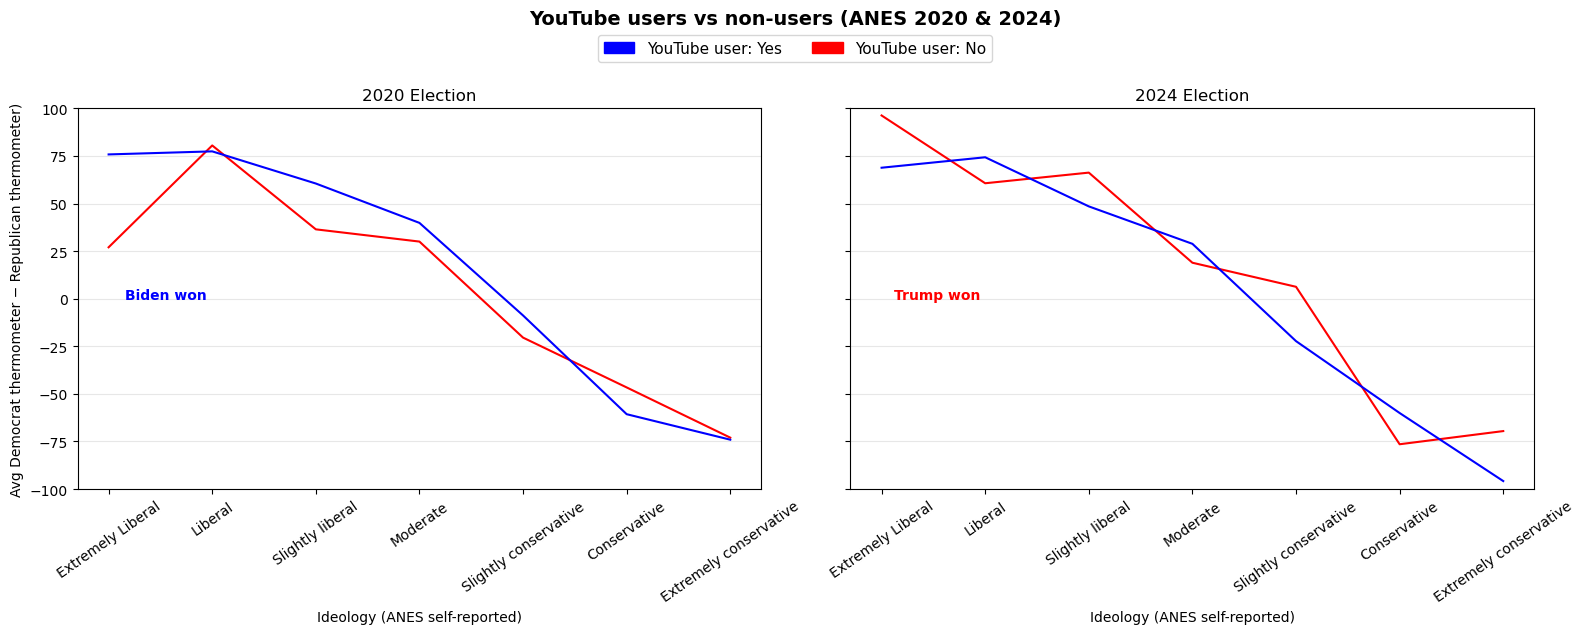

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ideology_order = ['Extremely Liberal', 'Liberal', 'Slightly liberal','Moderate', 'Slightly conservative', 'Conservative', 'Extremely conservative']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
years = [2020, 2024]
colors = {'Yes': 'blue', 'No': 'red'}

for ax, year in zip(axes, years):
    df_year = rq2_df[rq2_df['ELECTION_YEAR'] == year].copy()

    for youtube_use, group in df_year.groupby('YOUTUBE_USE'):
        group = group[group['LIB_CON_SCALE'].isin(ideology_order)].copy()
        group['ideology_rank'] = group['LIB_CON_SCALE'].map(
            {v: i for i, v in enumerate(ideology_order)}
        )
        group = group.sort_values('ideology_rank')

        ax.plot(
            group['LIB_CON_SCALE'],
            group['PARTISAN_LEAN'],
            label=f'YouTube user: {youtube_use}',
            color=colors[youtube_use]
        )

    winner = 'Biden won' if year == 2020 else 'Trump won'
    winner_color = 'blue' if year == 2020 else 'red'
    ax.annotate(winner, xy=(0.95, 0.05), ha='right', color=winner_color, fontweight='bold')
    ax.set_title(f'{year} Election')
    ax.set_xlabel('Ideology (ANES self-reported)')
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylim(-100, 100)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Avg Democrat thermometer − Republican thermometer)')
# legend
blue_patch = mpatches.Patch(color='blue', label='YouTube user: Yes')
orange_patch = mpatches.Patch(color='red', label='YouTube user: No')
fig.legend(handles=[blue_patch, orange_patch], loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('YouTube users vs non-users (ANES 2020 & 2024)', fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('rq2_partisan_lean.png')
plt.show()

# RQ3: Does YouTube comment sentiment reflect voter preferences or amplify extreme views?

In [33]:
connection, cursor = create_cursor()

rq3_query = """
SELECT
ch.channel_name,
v.lean,
v.year,
ROUND(AVG(c.sentiment_score), 3) AS avg_sentiment,
COUNT(*) AS comment_count
FROM youtube_comments c
JOIN youtube_videos v ON c.video_id = v.video_id
JOIN youtube_channels ch ON v.channel_id = ch.channel_id
GROUP BY ch.channel_name, v.lean, v.year
ORDER BY v.year, v.lean, ch.channel_name
"""

cursor.execute(rq3_query)
results = cursor.fetchall()
rq3_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
display(rq3_df.head())

cursor.close()
connection.close()

Connected to Oracle


,CHANNEL_NAME,LEAN,YEAR,AVG_SENTIMENT,COMMENT_COUNT
0,Ben Shapiro,conservative,2018,0.229,108
1,The Young Turks,liberal,2018,-0.025,5
2,Ben Shapiro,conservative,2019,0.240,108
3,The Young Turks,liberal,2019,-0.028,2
4,Ben Shapiro,conservative,2020,0.043,108


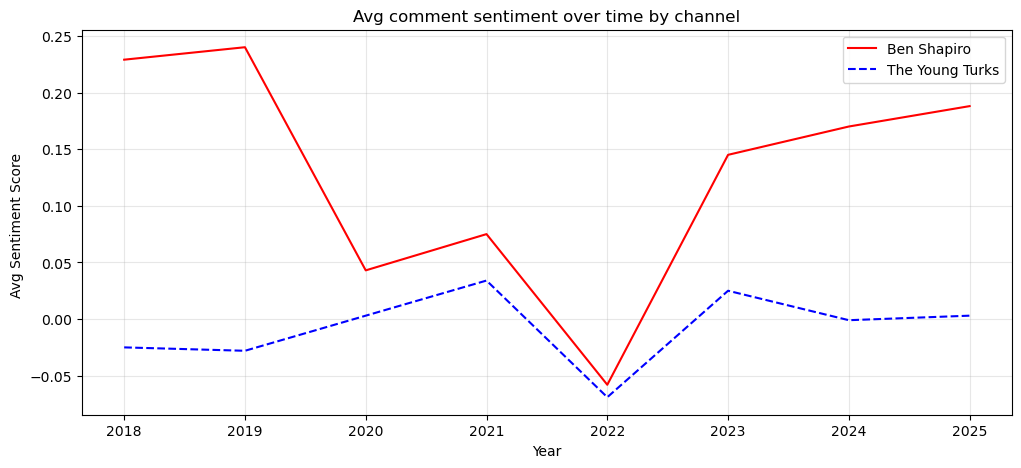

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

channel_colors = {
    'Ben Shapiro': 'red',
    'The Young Turks': 'blue',
}
channel_styles = {
    'Ben Shapiro':    '-',
    'The Young Turks': '--',
}

for channel, group in rq3_df.groupby('CHANNEL_NAME'):
    group = group.sort_values('YEAR')
    ax.plot(
        group['YEAR'],
        group['AVG_SENTIMENT'],
        label=channel,
        color=channel_colors[channel],
        linestyle=channel_styles[channel],
    )

ax.set_title('Avg comment sentiment over time by channel')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Sentiment Score ')
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('rq3_sentiment.png')
plt.show()